# Домашнее задание №3

In [51]:
import numpy as np
from hashlib import sha256

def check(image, ref_hash):
    image_hash = sha256(np.ascontiguousarray(image)).hexdigest()
    if image_hash == ref_hash:
        print("All good \U0001F44D")
    else:
        raise RuntimeError("Image hash differ: " + image_hash)

## Задание 1

Дописать функцию для вывода метрик PSNR и SSIM

In [52]:
import cv2
import skimage.metrics

def get_metrics_str(lhs_image, rhs_image):
    psnr = skimage.metrics.peak_signal_noise_ratio(lhs_image, rhs_image)
    ssim = skimage.metrics.structural_similarity(lhs_image, rhs_image)
    return str(f"PSNR = {psnr}\nSSIM = {ssim}")

## Задание 2

Преобразовать исходное изображение в градации серого

In [53]:
import cv2
import skimage
import skimage.io
from matplotlib import pyplot as plt

src_image_url = 'https://drive.google.com/u/0/uc?id=147ExaALbbRy6yN5szUCZd6G4tdJXIUIY&export=download'
src_image = skimage.io.imread(src_image_url)

In [54]:
gray_image = cv2.cvtColor(src_image, cv2.COLOR_RGB2GRAY)

In [55]:
check(gray_image, "26f1edc9bcde27b8e39f14cb7d46ce3057d4bfacd6d9ed4f47193a9fa435f340")

All good 👍


## Задание 3

Добавить на исходное изображение гауссов шум

In [56]:
import skimage.util

seed = 42

rng = np.random.default_rng(seed)
noised_image = skimage.util.random_noise(gray_image, mode='gaussian', rng=rng)
noised_image = (noised_image * 255).astype(np.uint8)

Text(0.5, 1.0, 'Noised image\nPSNR = 20.643167003109046\nSSIM = 0.23361041170268015')

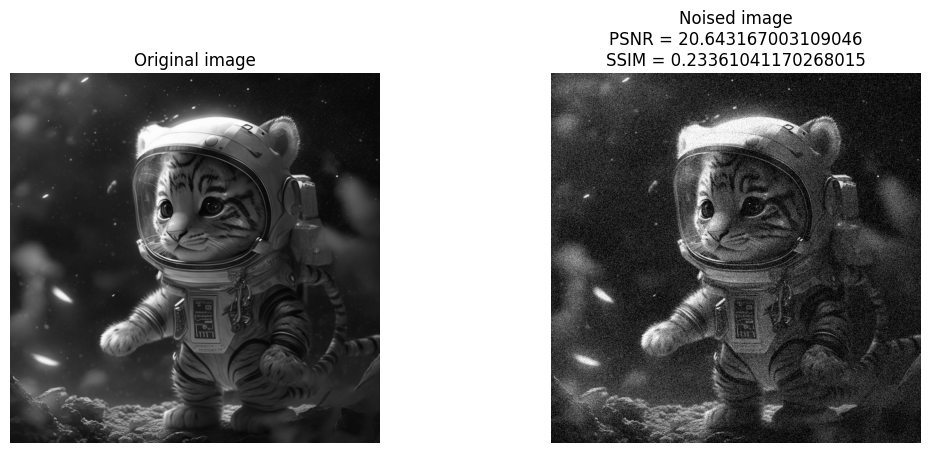

In [57]:
plt.figure(figsize=[6.4 * 2, 4.8])
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.axis("off")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Noised image\n" + get_metrics_str(gray_image, noised_image))

#check(noised_image, "890914194c06f8770573990853591633cf5cbbda73ee22dab40563a7ae99a68d")

## Задание 4

Провести фильтрацию среднеарифметическим фильтром

In [58]:
kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), dtype=np.float64) / (kernel_size * kernel_size)
blured_image = cv2.filter2D(noised_image, -1, kernel)

Text(0.5, 1.0, 'Blured image \nPSNR = 28.906439890611942\nSSIM = 0.6376661103284844')

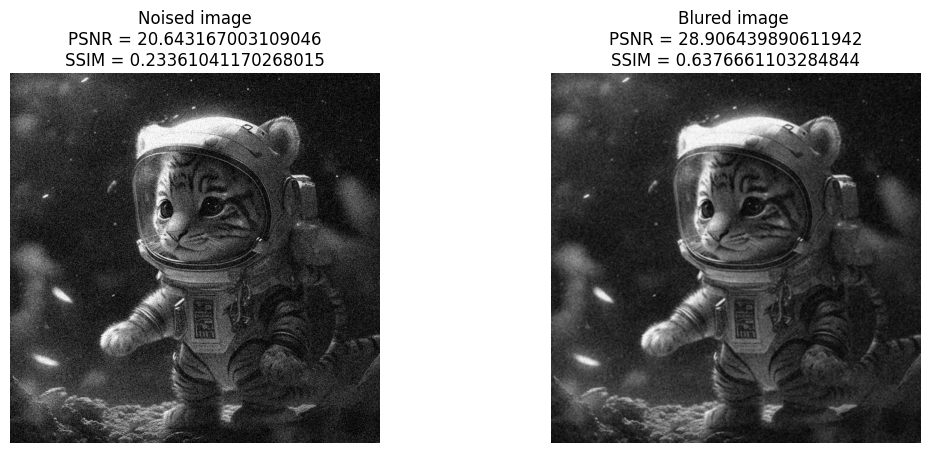

In [59]:
plt.figure(figsize=[6.4 * 2, 4.8])
plt.subplot(1, 2, 1)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Noised image\n" + get_metrics_str(gray_image, noised_image))

plt.subplot(1, 2, 2)
plt.imshow(blured_image, cmap='gray')
plt.axis("off")
plt.title("Blured image \n" + get_metrics_str(gray_image, blured_image))

#check(blured_image, "e06af1d5960cbb9f6eaecff9e75d2ad8c560878a43bb47d07a03e9e896d61b1f")

## Задание 5

Провести фильтрацию среднегеометрическим фильтром

In [60]:
from scipy.ndimage import generic_filter

kernel_size = 3

def geometric_mean(values):
    return np.exp(np.mean(np.log(values + 1e-10)))

blured_image = generic_filter(noised_image.astype(np.float64), geometric_mean, size=kernel_size).astype(np.uint8)

Text(0.5, 1.0, 'Blured image\nPSNR = 21.31336014782719\nSSIM = 0.3338869893533653')

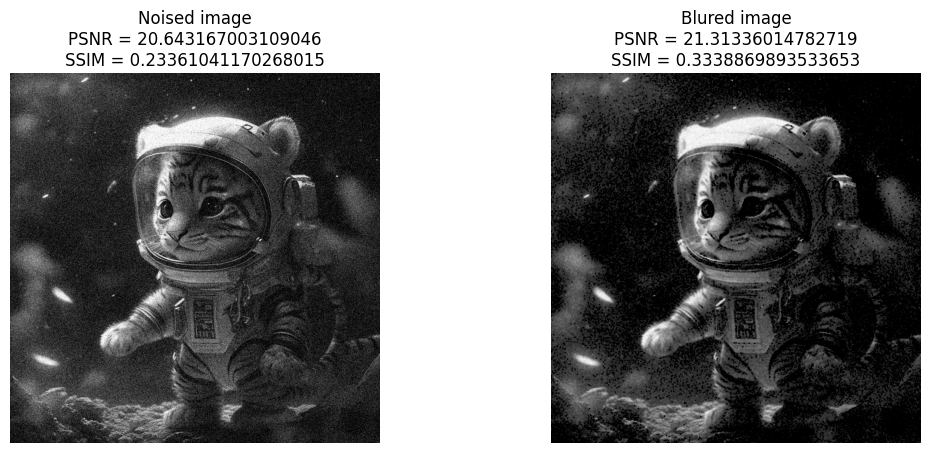

In [61]:
plt.figure(figsize=[6.4 * 2, 4.8])
plt.subplot(1, 2, 1)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Noised image\n" + get_metrics_str(gray_image, noised_image))

plt.subplot(1, 2, 2)
plt.imshow(blured_image, cmap='gray')
plt.axis("off")
plt.title("Blured image\n" + get_metrics_str(gray_image, blured_image))

## Задание 6

Преобразовать изображение в градации серого и добавить шум «соль и перец»

In [62]:
src_image_url = 'https://drive.google.com/u/0/uc?id=1oP3crmzAUkkpxeW6tuvhuZqXtry8_5_6&export=download'
src_image = skimage.io.imread(src_image_url)

In [63]:
import skimage.util

seed = 42
noise_power = 50

gray_image = cv2.cvtColor(src_image, cv2.COLOR_RGB2GRAY)
rng = np.random.default_rng(seed)
noised_image = gray_image.copy()
mask = rng.integers(0, 256, size=gray_image.shape)
noised_image[mask < noise_power] = 0
noised_image[mask >= 256 - noise_power] = 255

Text(0.5, 1.0, 'Noised image\nPSNR = 8.489516059182797\nSSIM = 0.01334899694591165')

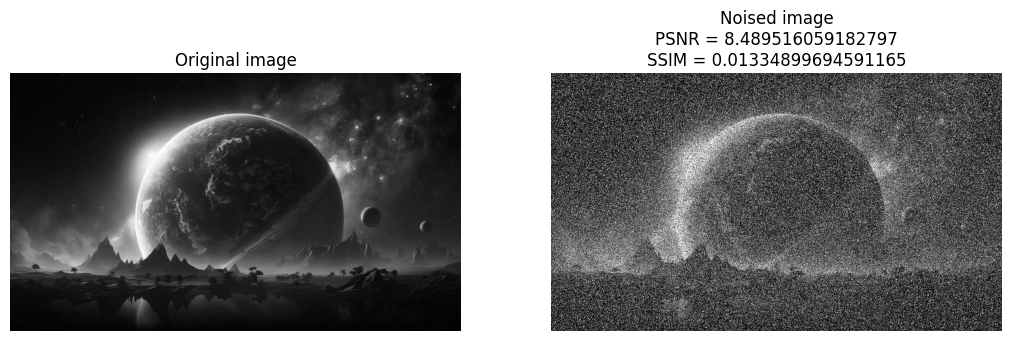

In [64]:
plt.figure(figsize=[6.4 * 2, 4.8])
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.axis("off")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Noised image\n" + get_metrics_str(gray_image, noised_image))

#check(noised_image, "b68027d668d01b0a49e3cb62f292a1bf9c8547e06e4f3b3c2ff1ae632b90c5a8")

## Задание 7

Провести трёхкратную фильтрацию медианным фильтром размера 3x3

In [65]:
median_size = 3
median_images = []
current = noised_image.copy()
for _ in range(3):
    current = cv2.medianBlur(current, median_size)
    median_images.append(current)

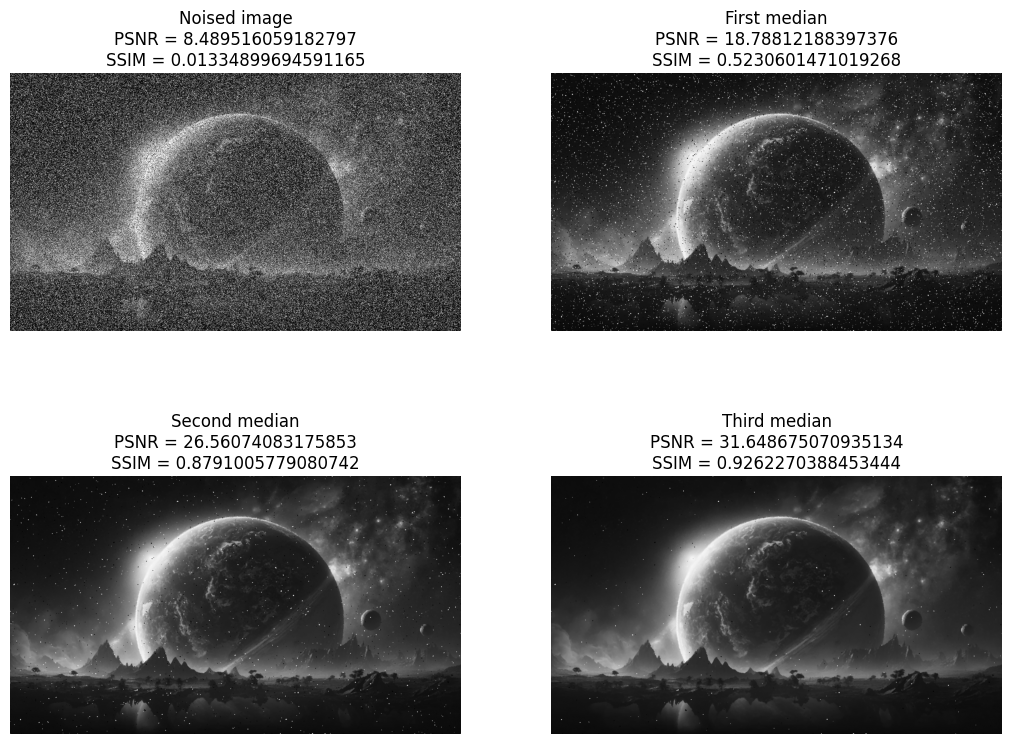

In [66]:
plt.figure(figsize=[6.4 * 2, 4.8 * 2])
plt.subplot(2, 2, 1)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Noised image\n" + get_metrics_str(gray_image, noised_image))

num_strs = ["First", "Second", "Third"]
for i in range(0, 3):
    plt.subplot(2, 2, 2 + i)
    plt.imshow(median_images[i], cmap='gray')
    plt.axis("off")
    plt.title(num_strs[i] + " median\n" + get_metrics_str(gray_image, median_images[i]))

## Задание 8

Провести трёхкратную адаптивную медианную фильтрацию

In [ ]:
import itertools
from scipy.ndimage import minimum_filter, maximum_filter, median_filter


def median_idx(y, x, size, img_shape):
    idx_arr = [[[y - 1, x], [y, x - 1], [y, x], [y, x + 1], [y + 1, x]],         
               [[y - 1, x - 1], [y - 1, x + 1], [y + 1, x - 1], [y + 1, x + 1]], 
               [[y - 2, x], [y, x - 2], [y, x + 2], [y + 2, x]],                 
               [[y - 2, x - 1], [y - 2, x + 1], [y - 1, x - 2], [y - 1, x + 2],
                [y + 2, x - 1], [y + 2, x + 1], [y + 1, x - 2], [y + 1, x + 2]]] 

    idx = itertools.chain(*idx_arr[0:size])
    idx = map(lambda pair: [min(max(pair[0], 0), img_shape[0] - 1), min(max(pair[1], 0), img_shape[1] - 1)], idx)
    return tuple(zip(*idx))


def _build_footprints():
    coords = [
        [(1,2),(2,1),(2,2),(2,3),(3,2)],
        [(1,1),(1,3),(3,1),(3,3)],
        [(0,2),(2,0),(2,4),(4,2)],
        [(0,1),(0,3),(1,0),(1,4),(3,0),(3,4),(4,1),(4,3)],
    ]
    fp = np.zeros((5,5), dtype=bool)
    fps = []
    for layer in coords:
        for r, c in layer:
            fp[r, c] = True
        fps.append(fp.copy())
    return fps

_footprints = _build_footprints()


def adapt_median(img):
    f = img.astype(np.float64)
    result = np.full_like(f, np.nan)
    for fp in _footprints:
        med, mn, mx = median_filter(f, footprint=fp), minimum_filter(f, footprint=fp), maximum_filter(f, footprint=fp)
        ok = np.isnan(result) & (med > mn) & (med < mx)
        result[ok] = np.where((f > mn) & (f < mx), f, med)[ok]
    result[np.isnan(result)] = median_filter(f, footprint=_footprints[-1])[np.isnan(result)]
    return result.astype(np.uint8)

In [68]:
adapt_median_images = []
current = noised_image.copy()
for _ in range(3):
    current = adapt_median(current)
    adapt_median_images.append(current)

Вывести PSNR и SSIM

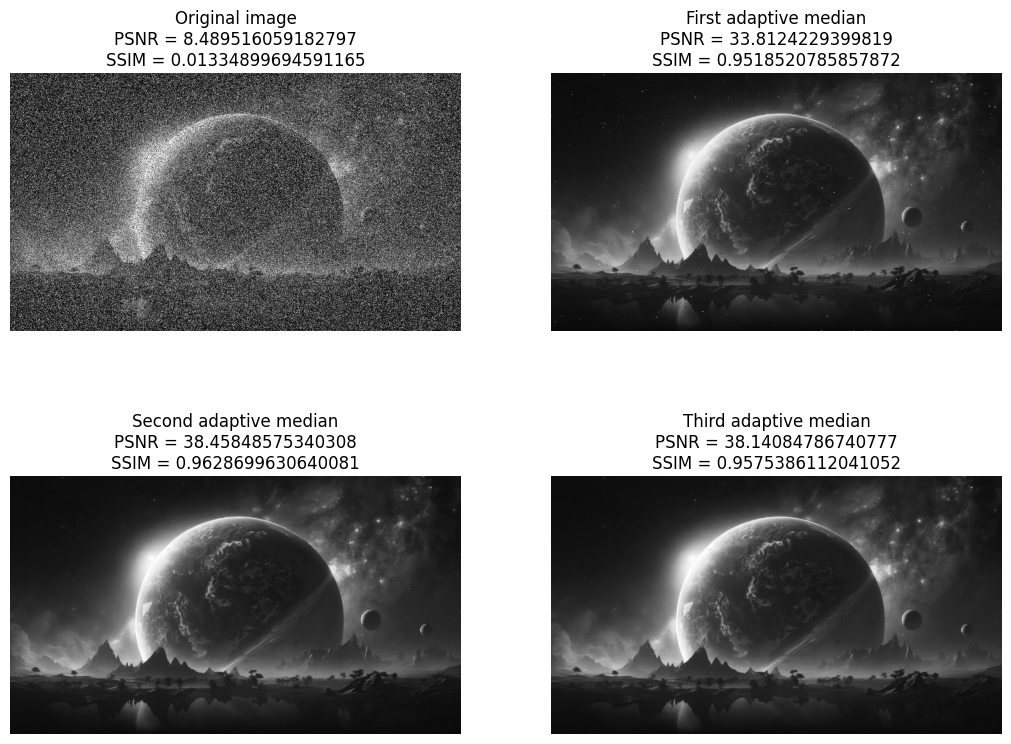

In [69]:
plt.figure(figsize=[6.4 * 2, 4.8 * 2])
plt.subplot(2, 2, 1)
plt.imshow(noised_image, cmap='gray')
plt.axis("off")
plt.title("Original image\n" + get_metrics_str(gray_image, noised_image))

num_strs = ["First", "Second", "Third"]
for i in range(0, 3):
    plt.subplot(2, 2, 2 + i)
    plt.imshow(adapt_median_images[i], cmap='gray')
    plt.axis("off")
    plt.title(num_strs[i] + " adaptive median\n" + get_metrics_str(gray_image, adapt_median_images[i]))

### Выполнил: Мелешенко Николай Артурович